In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

column_names = [
    'FILENAME', 'CAT', 'ML_MixR', 'ML_CAPE', 'ML_CIN',
    'ML_LCL_MAGL', 'SRhelicity_0_1', 'Shear_0_6', 'STP_C', 'T_500',
    'WindDir_500', 'LR_7_5', 'Shear_0_3', 'Shear_0_9', 'SRhelicity_0_3'
]

# Wind variables in knots,
# ML_CAPE, ML_CIN in j*kg^-1
# ML_LCL in meters above ground level
# LR_7_5: 700-500mb lapse rate in C*km^-1
# SRhelicity: m^2*s^-2

# Formatting adjustment so the dataset is handled correctly by Pandas
X = pd.read_csv(
    'sars_supercell.txt',
    sep=r'\s+',
    skiprows=1,
    names=column_names,  # Applies our clean list of 15 names defined above
    usecols=range(15)    # Strictly only reads the first 15 fields, ignoring the trailing tabs
)

print(X.head())
print(f"\nDataset shape: {X.shape}")



       FILENAME  CAT  ML_MixR  ML_CAPE  ML_CIN  ML_LCL_MAGL  SRhelicity_0_1  \
0  00042320.TXK    2     12.9     1702      -1          657             134   
1  00042001.PPF    2     13.5     2614     -50         1216             227   
2  00032900.FTW    2     13.1     2058     -42         1069              83   
3  00032304.SJT    2     11.9     1680    -119          896             119   
4  00031622.ATT    2      9.4     1019      -7         1566              12   

   Shear_0_6  STP_C  T_500  WindDir_500  LR_7_5  Shear_0_3  Shear_0_9  \
0       61.7    2.3  -14.0          250     6.5       32.8       76.6   
1       59.9    4.7  -12.9          234     7.5       39.7       73.5   
2       49.7    1.3  -15.2          245     8.0       21.9       87.1   
3       61.1    1.1  -15.5          212     9.1       38.4       66.9   
4       45.8    0.0  -17.5          249     8.0       34.4       53.7   

   SRhelicity_0_3  
0             166  
1             244  
2             126  
3     

In [2]:
X['SigTor'] = np.where(X['CAT'] == 2, 1, 0)
X['AnyTor'] = np.where(X['CAT'] >= 1, 1, 0)

sigtors = X['SigTor'].sum()
sigtorprop = sigtors / len(X)
sigtorpercent = sigtorprop * 100
print(f"The dataset contains {sigtors} significant tornadic supercells. This is {sigtorpercent} percent of the dataset.")

The dataset contains 203 significant tornadic supercells. This is 21.641791044776117 percent of the dataset.


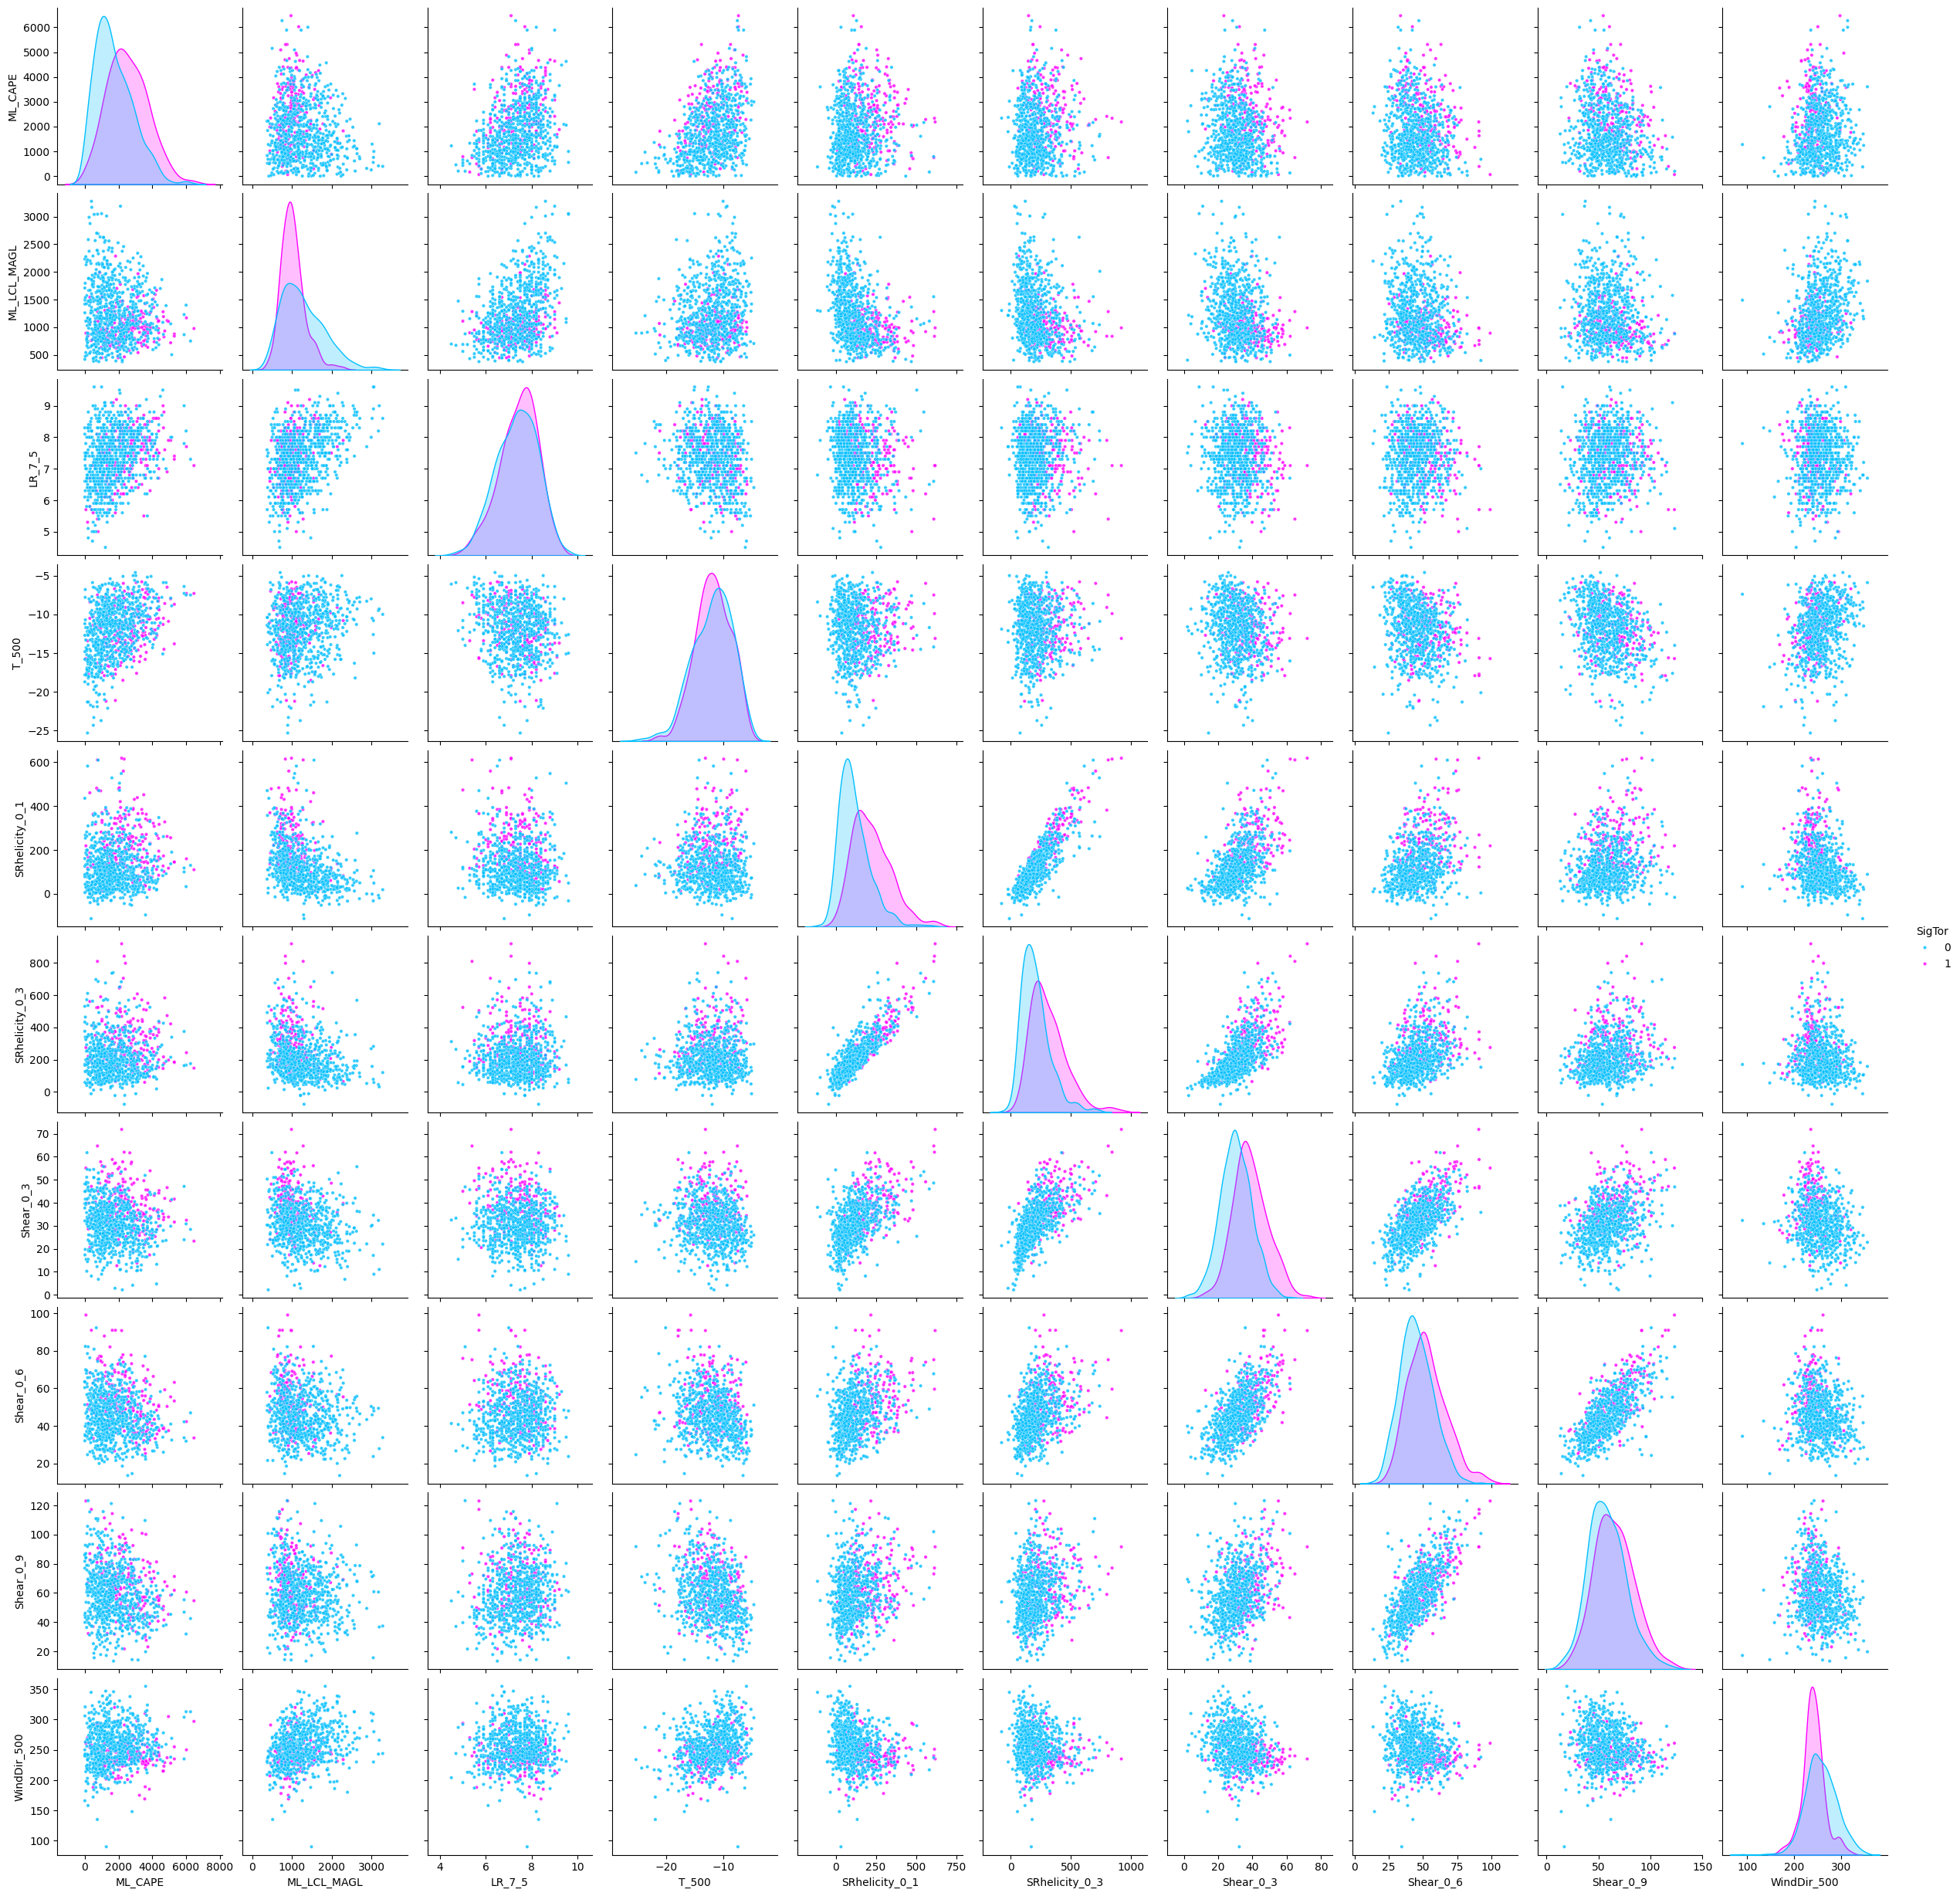

In [3]:

sns.pairplot(data=X, hue='SigTor', vars=['ML_CAPE',
    'ML_LCL_MAGL', 'LR_7_5', 'T_500', 'SRhelicity_0_1', 'SRhelicity_0_3',
    'Shear_0_3', 'Shear_0_6', 'Shear_0_9', 'WindDir_500'], palette={0: 'deepskyblue', 1: 'fuchsia'}, diag_kind='kde', plot_kws={'alpha': 0.8, 's': 10},
    diag_kws={'common_norm': False})
plt.show()


<Axes: xlabel='ML_LCL_MAGL', ylabel='Proportion'>

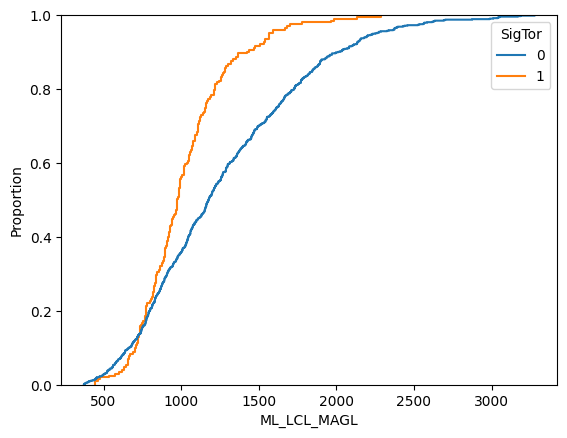

In [4]:

# sns.ecdfplot(data=X, x='ML_LCL_MAGL', hue='SigTor')


In [5]:
# For our initial model, we will start with the following predictors based on class separability in our pairs plot

X_predictors = X[['ML_CAPE', 'ML_LCL_MAGL', 'SRhelicity_0_1', 'SRhelicity_0_3', 'Shear_0_3', 'WindDir_500']]
y = X['SigTor']


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# sklearn uses L2 ("Ridge") penalty by default for logistic regression, this requires scaling/regularization
# Since the data represents physical, meteorological measurements, we will choose to exclude a penalty term
# This allows us to preserve full interpretability of physical units and dimensional consistency
logreg = LogisticRegression(penalty=None, max_iter=5000, random_state=123)


# We still use StratifiedKFold to ensure the folds represent your actual dataset accurately.
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

cv_results = cross_validate(
    logreg,
    X_predictors,
    y,
    cv=kf,
    scoring=['accuracy', 'roc_auc', 'neg_brier_score'],
    return_train_score=False
)

print(f"Mean CV Accuracy: {cv_results['test_accuracy'].mean():.3f}")
print(f"Mean CV ROC-AUC:  {cv_results['test_roc_auc'].mean():.3f}\n")
print(f"Mean CV Brier Score: {-cv_results['test_neg_brier_score'].mean():.3f}")

Mean CV Accuracy: 0.837
Mean CV ROC-AUC:  0.854

Mean CV Brier Score: 0.116


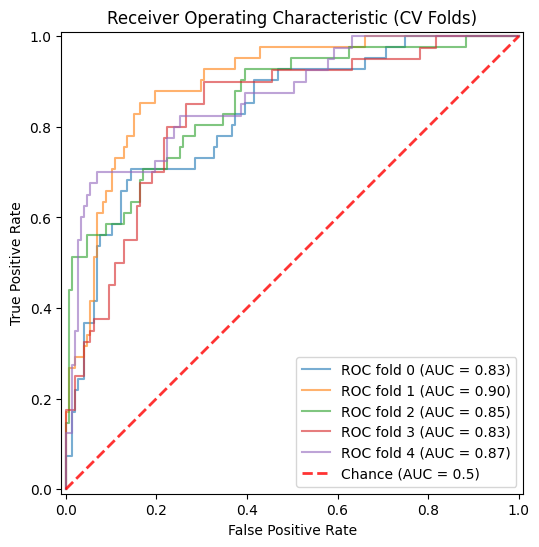

In [7]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))


for fold, (train_idx, test_idx) in enumerate(kf.split(X_predictors, y)):

    X_train_fold = X_predictors.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_test_fold = X_predictors.iloc[test_idx]
    y_test_fold = y.iloc[test_idx]


    logreg.fit(X_train_fold, y_train_fold)

    RocCurveDisplay.from_estimator(
        logreg,
        X_test_fold,
        y_test_fold,
        name=f"ROC fold {fold}",
        alpha=0.6,
        lw=1.5,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance (AUC = 0.5)", alpha=0.8)
ax.set_title("Receiver Operating Characteristic (CV Folds)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

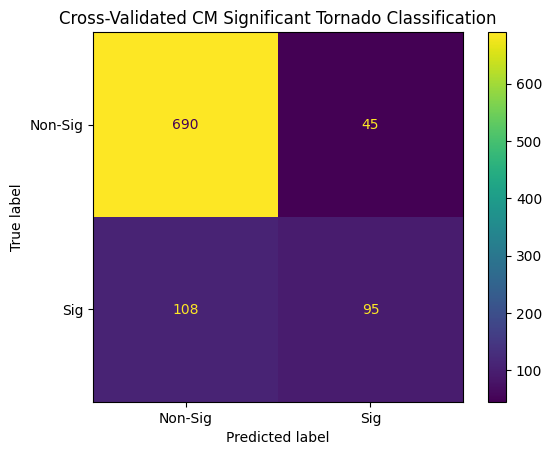

In [8]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_cv_pred = cross_val_predict(logreg, X_predictors, y, cv=kf)

cm = confusion_matrix(y, y_cv_pred)

ConfusionMatrixDisplay(cm, display_labels=['Non-Sig', 'Sig']).plot()

plt.title("Cross-Validated CM Significant Tornado Classification")
plt.show()


In [12]:
cm_df = pd.DataFrame(cm, index=['Non-Sig', 'Sig'], columns=['Non-Sig', 'Sig'])
print(cm_df)

tpr = cm_df.iloc[1, 1] / (cm_df.iloc[1, 1] + cm_df.iloc[0, 1])
tnr = cm_df.iloc[0, 0] / (cm_df.iloc[0, 0] + cm_df.iloc[1, 0])
tss = tpr + tnr - 1

print(f"TPR: {tpr:.3f}")
print(f"TNR: {tnr:.3f}")
print(f"TSS: {tss:.3f}")

#


         Non-Sig  Sig
Non-Sig      690   45
Sig          108   95
TPR: 0.679
TNR: 0.865
TSS: 0.543


References:

Dataset courtesy of

Jewell, R., 2010: The Sounding Analog Retrieval System (SARS). Preprints, 25th Conf. Severe Local Storms, Denver CO.

Downloaded via
https://github.com/sharppy/SHARPpy/tree/main/sharppy/databases/sars

This notebook and model are for demonstration purposes only and the author does not recommend using the model for decision making.